# Project 03: Gibbs Sampling (Random Algorithm)

In [1]:
import random
import numpy as np
import bamnostic as bs
import seqlogo #remove sl to match untouched driver function

#import function for building sequence motif & idenfitying seqs matching to motif
from data_readers import *
from seq_ops import get_seq
from motif_ops import *

---
## Implement Gibbs Sampler


Gibbs sampling is a MCMC approach to identify enrichments. Here we will implement a method to identify motifs from a set of regions. 

Important considerations:
- We will need to score each sequence with a PWM using the `score_kmer()` or `score_sequence()` functions
    - You will need to investigate into the help documenation and libraries to identify how best to use these functions. 
- These sites are often not strand-specific and so both scores on the negative as well as positive strand should be considered
- To select a random sequence, use `random.randint()` or `numpy.random.randint()`
- To select a new position $m$ (as defined below) use `random.choices()` or `numpy.random.choice()`  

Assumptions: 
- We know $k$ as the length of expected motif
- Each sequence contains the motif



```
GibbsMotifFinder(DNA, k-length)
    random pick of k-length sequences from each line of DNA as Motifs
    for j ← 1 to 10000 or Motifs stops changing
        i ← Random(N) where N is number of DNA entries
        PWM ← PWM constructed from all Motifs except for Motifi
        Motifi ← select position m from PWM-scored k-mers in DNAi in probabilistic fashion from score distribution
    return PFM
```

Probability of chosing position $m = \frac{A_{m}}{\sum_{l}A_{l}}$ for positions $l$ in DNAi


**Note:** I have also added a function to `motif_ops.py` that will calculate the information content of your motifs. This is useful to observe the progression of your Gibbs sampler as well as a measure of convergence. You can use this function as `IC = pfm_ic(pfm)`. You should expect a slow increase of IC until it plateaus such as in the plot below from your lecture slides:

<center><img src='figures/Gibbs_Sampling.png'/ width=600px></center>

---
# Project Start

In [10]:
def GibbsMotifFinder(seqs, k, seed=None, ic_window=100, max_iterations=10000):
    '''
    Function to find a pfm from a list of strings using a Gibbs sampler

    Args:
        seqs (str list): a list of sequences, not necessarily in same lengths
        k (int): the length of motif to find
        seed (int, default=None): seed for np.random
        ic_window (int, default=100): window size for IC
        max_iterations (int, default=10000): maximum number of iterations

    Returns:
        pfm (numpy array): dimensions are 4xlength
    '''
    # ---------- 0. Set up ----------
    # Seed once globally, now so that ALL random picks below use it
    random.seed(seed)
    # Safety check: stop the loop if IC window and/or Max iterations is 0 or negative
    if ic_window < 1 or max_iterations < 1:
        raise ValueError('ic_window and max_iterations must be at least 1')
    # Clean input: uppercase, sequences longer than k
    seqs = [s.upper() for s in seqs if len(s) >= k]
    N = len(seqs)

    # ---------- 1. Initialization ----------
    # Randomly assign initial motif position, for each sequence
    # Empty list to store one k-letter guess per sequence:
    motifs = []
    # For each sequence:
    for s in seqs:
        # Pick random start spot m, make sure k is inside the sequence
        m = random.randint(0, len(s) - k)
        # Cut the m-starting k letters out, put them in list above
        motifs.append(s[m:m + k])

    # ---------- 2. Iteration ----------
    # To improve one sequence's guess, using other's current guesses as a reference
    # Empty list to record the information content after every round
    ic_history = []
    # Loop up to 10000 times,
    for j in range(max_iterations):
        # a.Choose a random sequence to leave out of this round
        i = random.randint(0, N - 1)

        # b. Create motifs and background models from all other sequences
        # List of motifs for every remaining / unchosen sequence
        others = motifs[:i] + motifs[i + 1:]
        # Call on imported functions in helper file motif_ops.py
        # Count the frequency of letters at each position within motifs
        pfm = build_pfm(others, k)
        # Convert counts to PWM, in the imported function, uniform probabilities for non-motifs is bg = 0.25
        pwm = build_pwm(pfm)

        # c. Score all possible motifs in chosen sequence against PWM
        seq = seqs[i]  #chosen seq
        # Empty list for every possible motif k-mer in chosen seq and its PWM score
        candidate_motifs = []
        scores = []
        # Slide the k-letter window across the chosen seq and for each spot, loop as following:
        for m in range(len(seq) - k + 1):
            # Cut out the k-letters at spot m, safety check (ACGT)
            kmer = seq[m:m + k]
            if set(kmer) <= set('ACGT'):
                # Try the window as written AND its reverse complement,
                # use imported function reverse_complement(seq) from motif_ops.py of which imported from seq_ops
                for cand in (kmer, reverse_complement(kmer)):
                    # Save the candidate kmer
                    candidate_motifs.append(cand)
                    # Score = Sum of PWM value for each letter/ position: score_kmer() is from motif_ops.py
                    scores.append(score_kmer(cand, pwm))
        #Move on if window is not usable:
        if not candidate_motifs:
            continue

        #d. Choose new motif based on score distribution
        # Turn score list into numpy array
        scores = np.array(scores)
        #Undo log2 so PWM scores are positive
        A = 2.0 ** scores
        # Probability per candidate
        probs = A / A.sum()
        # Pick one random candidate, weighted by its probs
        new_motifs = random.choices(candidate_motifs, probs, k=1)[0]
        # Replace old pick with new pick / winning candidate
        motifs[i] = new_motifs

        #e. Convergence check - Has IC stopped changing?
        # Call on imported functions in helper file motif_ops.py
        # and count the frequency of letters at each position within (ALL) motifs
        pfm = build_pfm(motifs, k)
        # Score the sharpness of motif / measurement of IC
        ic = pfm_ic(pfm)
        # Record its information content
        ic_history.append(ic)
        # Print IC every 1000 iteration for sanity check
        if j % 1000 == 0:
            print(f"Iteration {j}: IC = {ic:.2f}")
        # Check for convergence once there are enough rounds recorded
        if len(ic_history) > ic_window:
            # Take the most recent IC values (this round + the ic_window before it)
            recent = ic_history[-(ic_window + 1):]
            # If they're all (basically) the same => IC has stopped changing and the motifs have converged => exit
            if np.allclose(recent, recent[0]):
                break

        # ---------- 3. Return ----------
        # Count letters across ALL final motifs and return the 4 rows (ACGT) x k PFM
    return build_pfm(motifs, k)


In [3]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

#read promoters, store in a list of strings
seq_file="data/GCF_000009045.1_ASM904v1_genomic.fna"
gff_file="data/GCF_000009045.1_ASM904v1_genomic.gff"

seqs = []

for name, seq in get_fasta(seq_file): # For each entry in our FASTA file
    for gff_entry in get_gff(gff_file): # For each entry in our GFF file
        if gff_entry.type == 'CDS': # If this is a coding sequence
            promoter_seq = get_seq(seq, gff_entry.start, gff_entry.end, gff_entry.strand, 50) # Extract 50 bp as a promoter
    
            """
            Because the gibbs sampling assumption is broken in just using promoters,
            and because it takes very long time to randomly progress through so many
            regions, for this example we will pre-filter for sequences that all contain
            part of the shine-dalgarno motif:
            """
            if "AGGAGG" in promoter_seq:
                seqs.append(promoter_seq)

---
# Driver Program
Don't change any of the code here. If you have completed the project by following the coding by contract, the following code should work.

Iteration 0: IC = 0.80
Iteration 1000: IC = 1.97
Iteration 2000: IC = 3.51
Iteration 3000: IC = 4.57
Iteration 4000: IC = 5.58
Iteration 5000: IC = 7.39
Iteration 6000: IC = 10.07
Iteration 7000: IC = 11.77
Iteration 8000: IC = 12.28
Iteration 9000: IC = 12.53


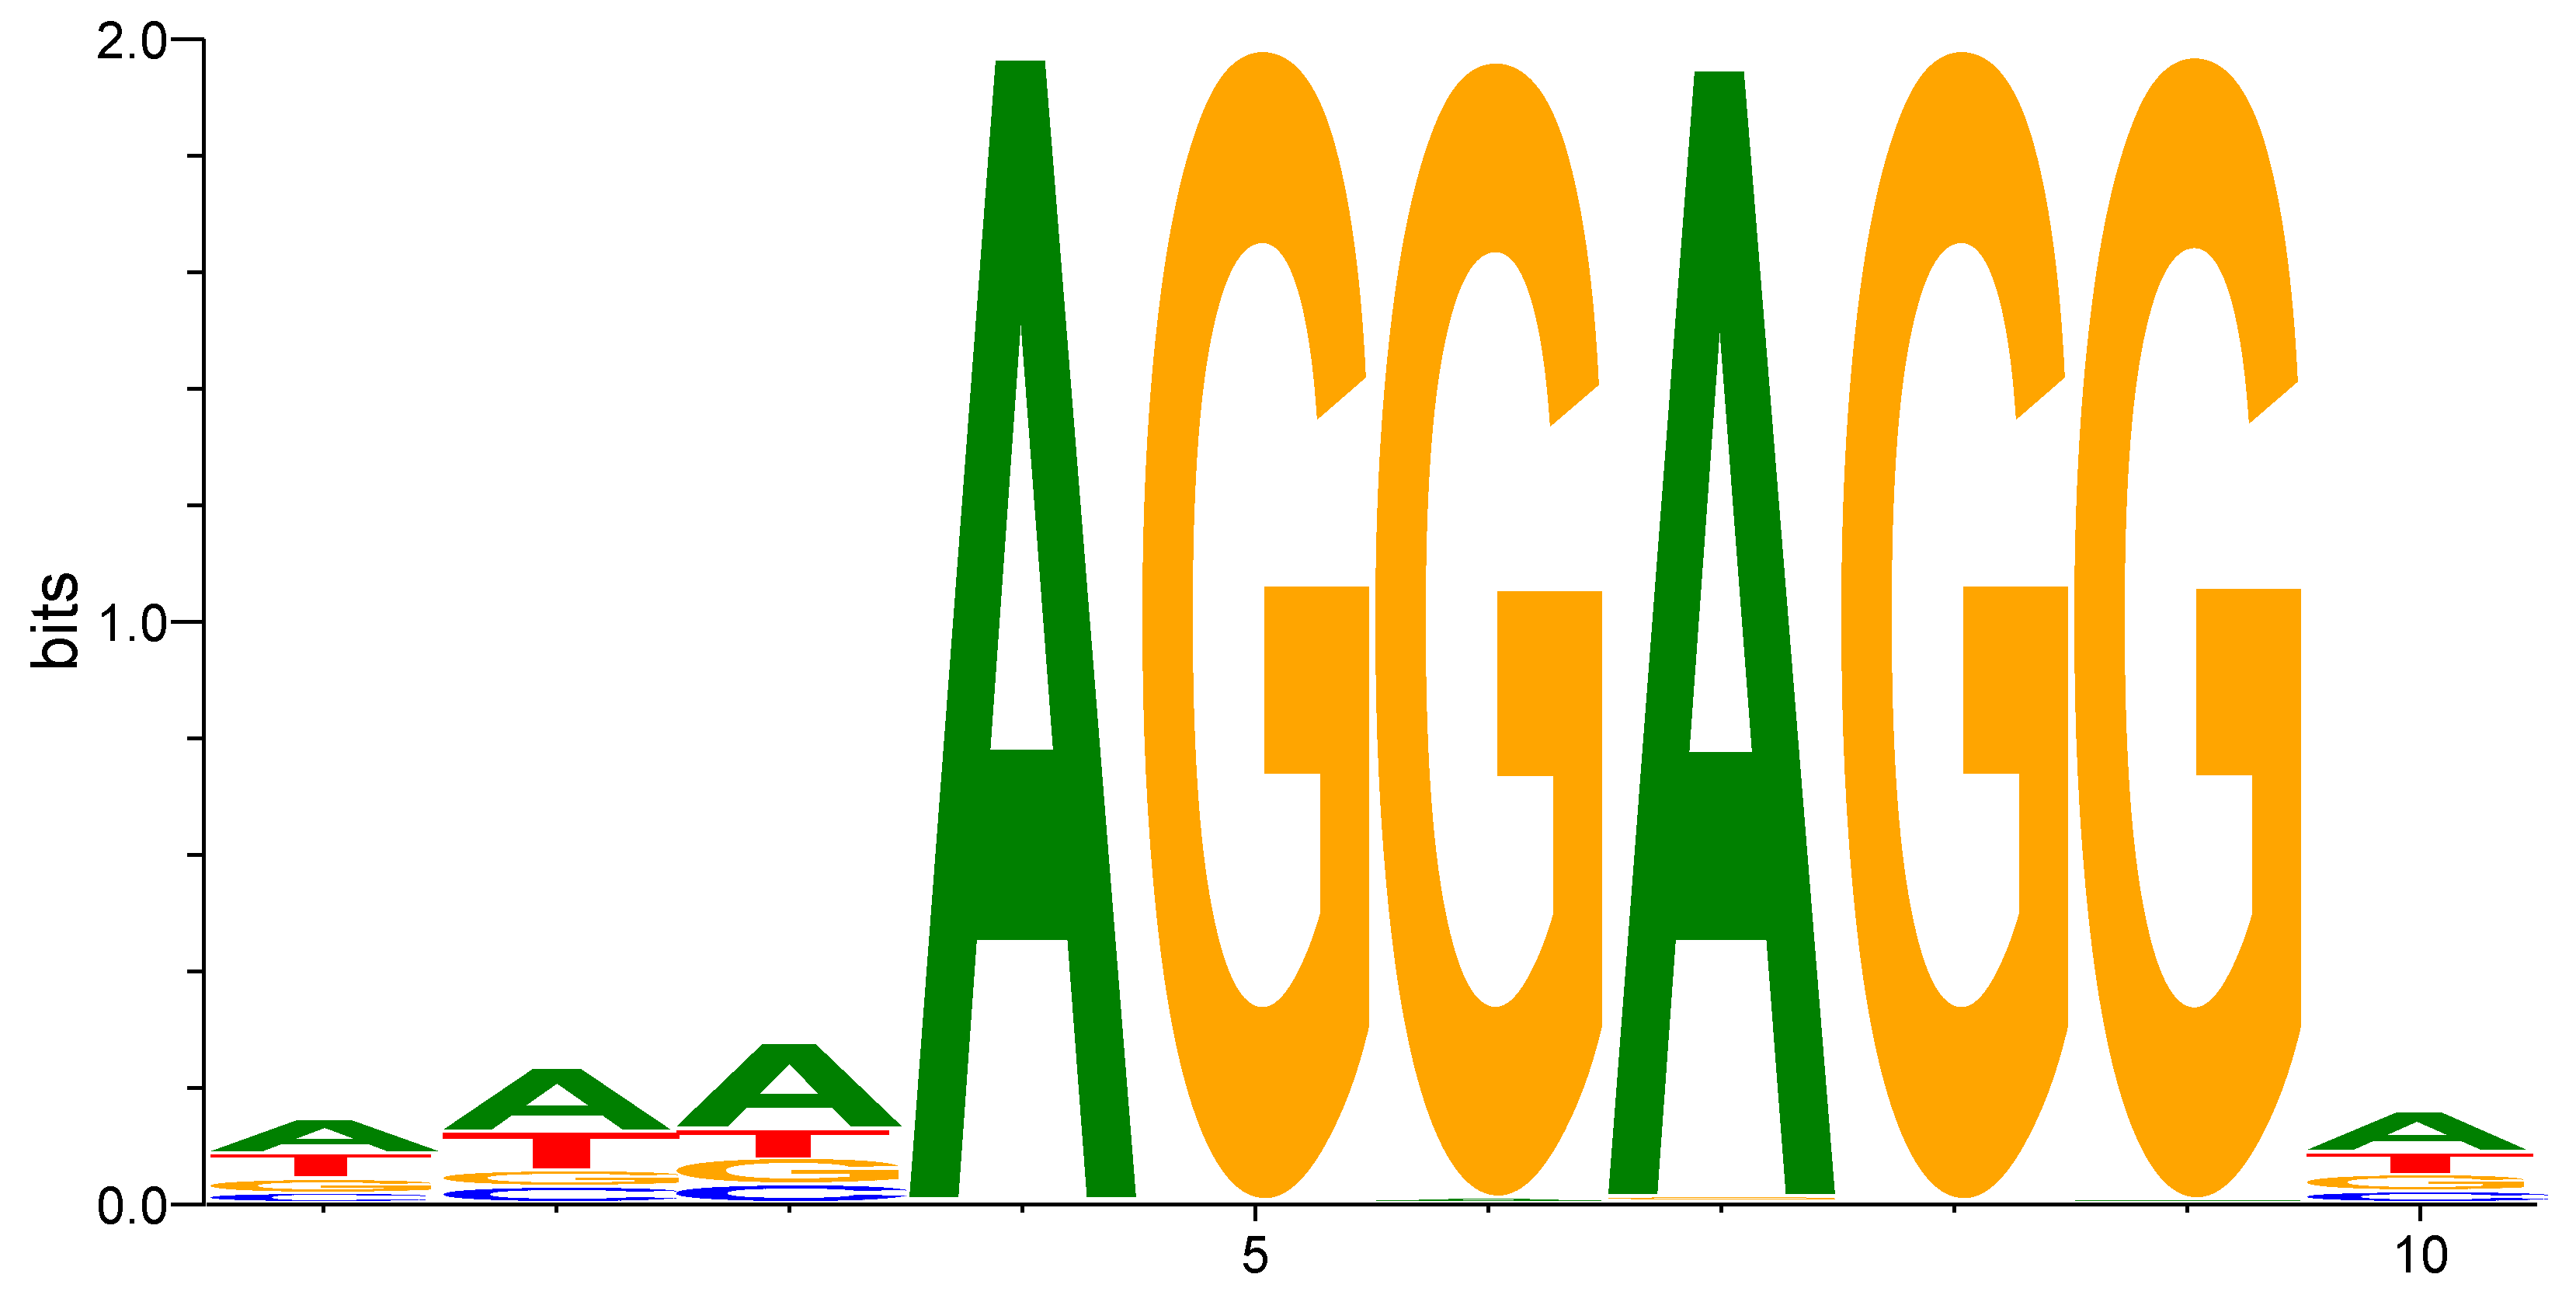

In [16]:
# Run the gibbs sampler:
promoter_pfm = GibbsMotifFinder(seqs,10 )

# Plot the final pfm that is generated: 
seqlogo.seqlogo(seqlogo.CompletePm(pfm = promoter_pfm.T))

In [15]:
# Print result with % for easy interpretation :
print(promoter_pfm)
print(pfm_ic(promoter_pfm))
total = int(promoter_pfm.sum(axis=0)[0])
bases = ['A', 'C', 'G', 'T']

for pos in range(promoter_pfm.shape[1]):
    col = promoter_pfm[:, pos]
    winner = bases[col.argmax()]
    pct = col.max() / total * 100
    print(f"Pos {pos+1}: {winner} ({pct:.0f}%)")

[[341 397 451 832   9   4 828   7   5 379]
 [ 96  99 100   0   0   0   0   0   1 102]
 [150 106 126   3 824 831   7 828 831 152]
 [250 235 160   2   4   2   2   2   0 204]]
12.273393854784329
Pos 1: A (41%)
Pos 2: A (47%)
Pos 3: A (54%)
Pos 4: A (99%)
Pos 5: G (98%)
Pos 6: G (99%)
Pos 7: A (99%)
Pos 8: G (99%)
Pos 9: G (99%)
Pos 10: A (45%)


---
# Challenge Yourself
Now that you potentially have a working skeleton of the project, try to work with the new NRF1 ChIP-seq data: `data/nrf1_gibbs.fa`.

Upon inspection, you will see that it is just a FASTA file. Since it is a FASTA file, you already have an example in the code above on how to access FASTA files. It is up to you to do the correct data ingest with it, though.

---
# NRF1 Driver Program
Modify the code below and test your Gibbs Sampler.

In [7]:
# Check on dataset to see the reason for long running time and set expectation for wait time
print(len(nrf1_peaks))
print(len(nrf1_peaks[0]) if nrf1_peaks else "empty")

90061
75


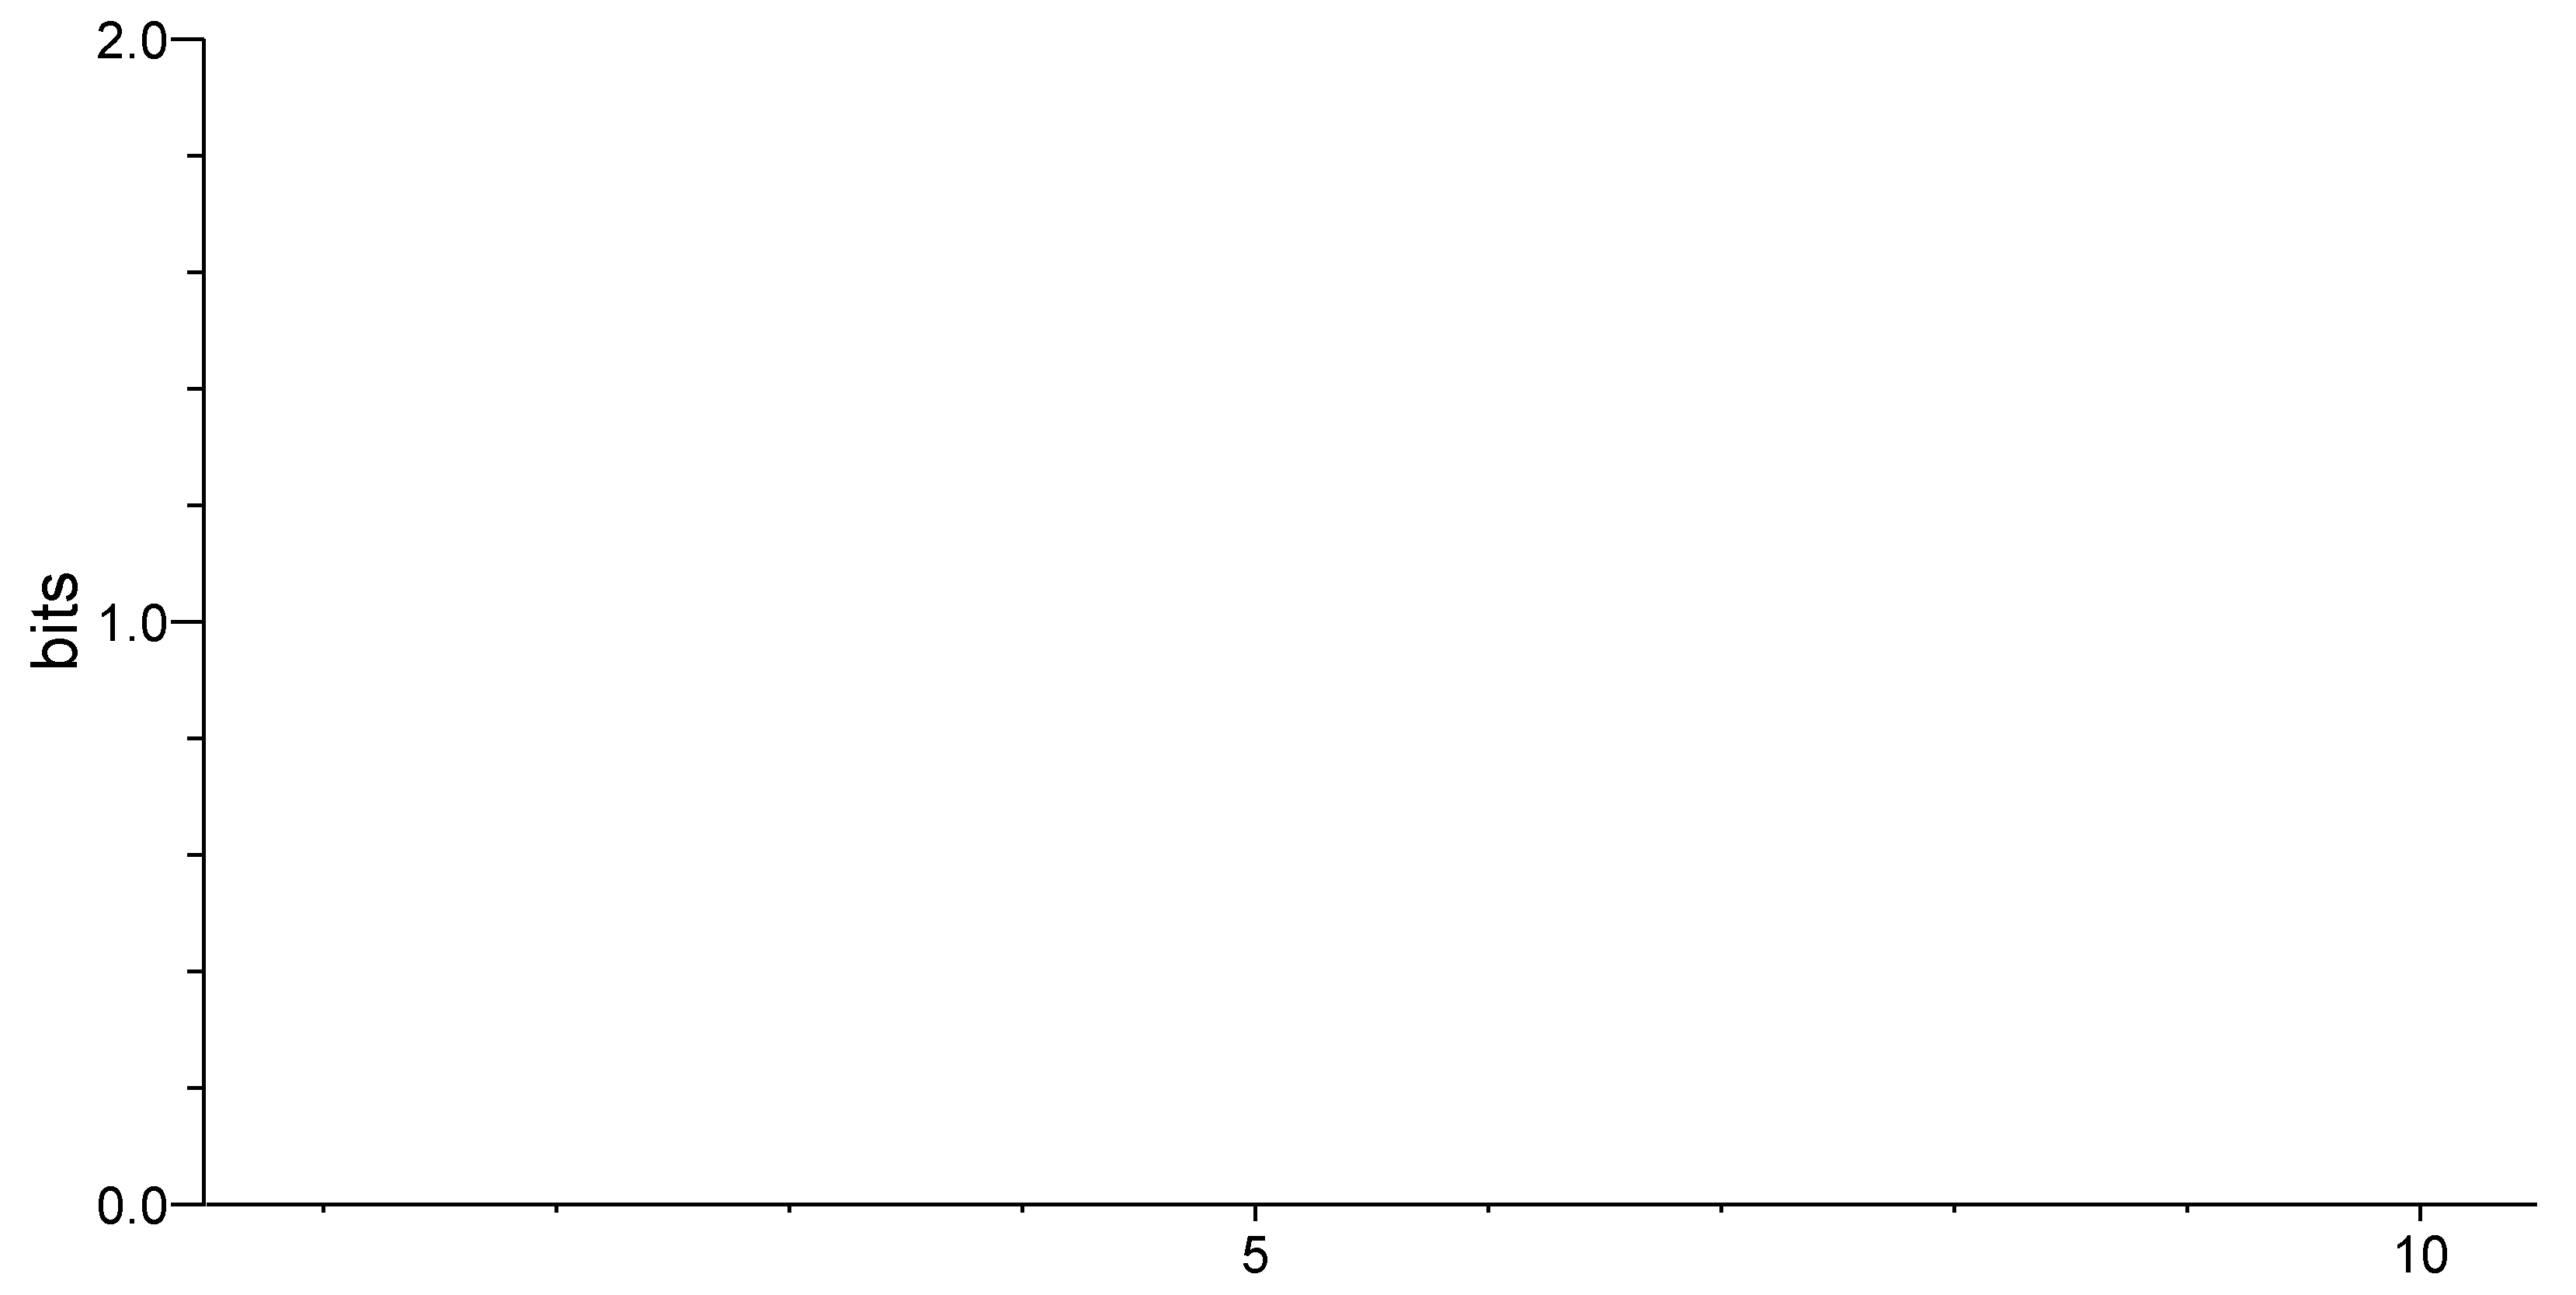

In [8]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

#read promoters, store in a list of strings
nrf1_file = "data/nrf1_gibbs.fa"

nrf1_peaks = []

#TODO: Data ingest of nrf1_peaks
# Read each FASTA entry and keep just the seq (uppercase)
for name, seq in get_fasta(nrf1_file):
    nrf1_peaks.append(seq.upper())

# Run the gibbs sampler:
nrf1_pfm = GibbsMotifFinder(nrf1_peaks, 10)

# Plot the final pfm that is generated:
seqlogo.seqlogo(seqlogo.CompletePm(pfm=nrf1_pfm.T))

In [13]:
# Print result with % for easy interpretation :
print(nrf1_pfm)
print(pfm_ic(nrf1_pfm))
bases = ['A', 'C', 'G', 'T']
k = nrf1_pfm.shape[1]
total = int(nrf1_pfm.sum(axis=0)[0])

labels = []
for pos in range(k):
    col = nrf1_pfm[:, pos]
    winner = bases[col.argmax()]
    pct = col.max() / total * 100
    labels.append(f"Pos {pos+1}({winner}, {pct:.0f}%)")
print(' | '.join(labels))

[[19443 19526 19476 19191 19239 19122 19270 19268 19361 19090]
 [25888 25782 25478 25822 25770 25722 25776 25663 25743 25921]
 [25863 25609 25713 25829 25910 25787 25951 25859 25621 25939]
 [18867 19144 19394 19219 19142 19430 19064 19271 19336 19111]]
0.15271642694372956
Pos 1(C, 29%) | Pos 2(C, 29%) | Pos 3(G, 29%) | Pos 4(G, 29%) | Pos 5(G, 29%) | Pos 6(G, 29%) | Pos 7(G, 29%) | Pos 8(G, 29%) | Pos 9(C, 29%) | Pos 10(G, 29%)


Iteration 0: IC = 0.11
Iteration 1000: IC = 0.38
Iteration 2000: IC = 0.53
Iteration 3000: IC = 0.70
Iteration 4000: IC = 0.83
Iteration 5000: IC = 1.19
Iteration 6000: IC = 1.47
Iteration 7000: IC = 1.85
Iteration 8000: IC = 2.24
Iteration 9000: IC = 2.71


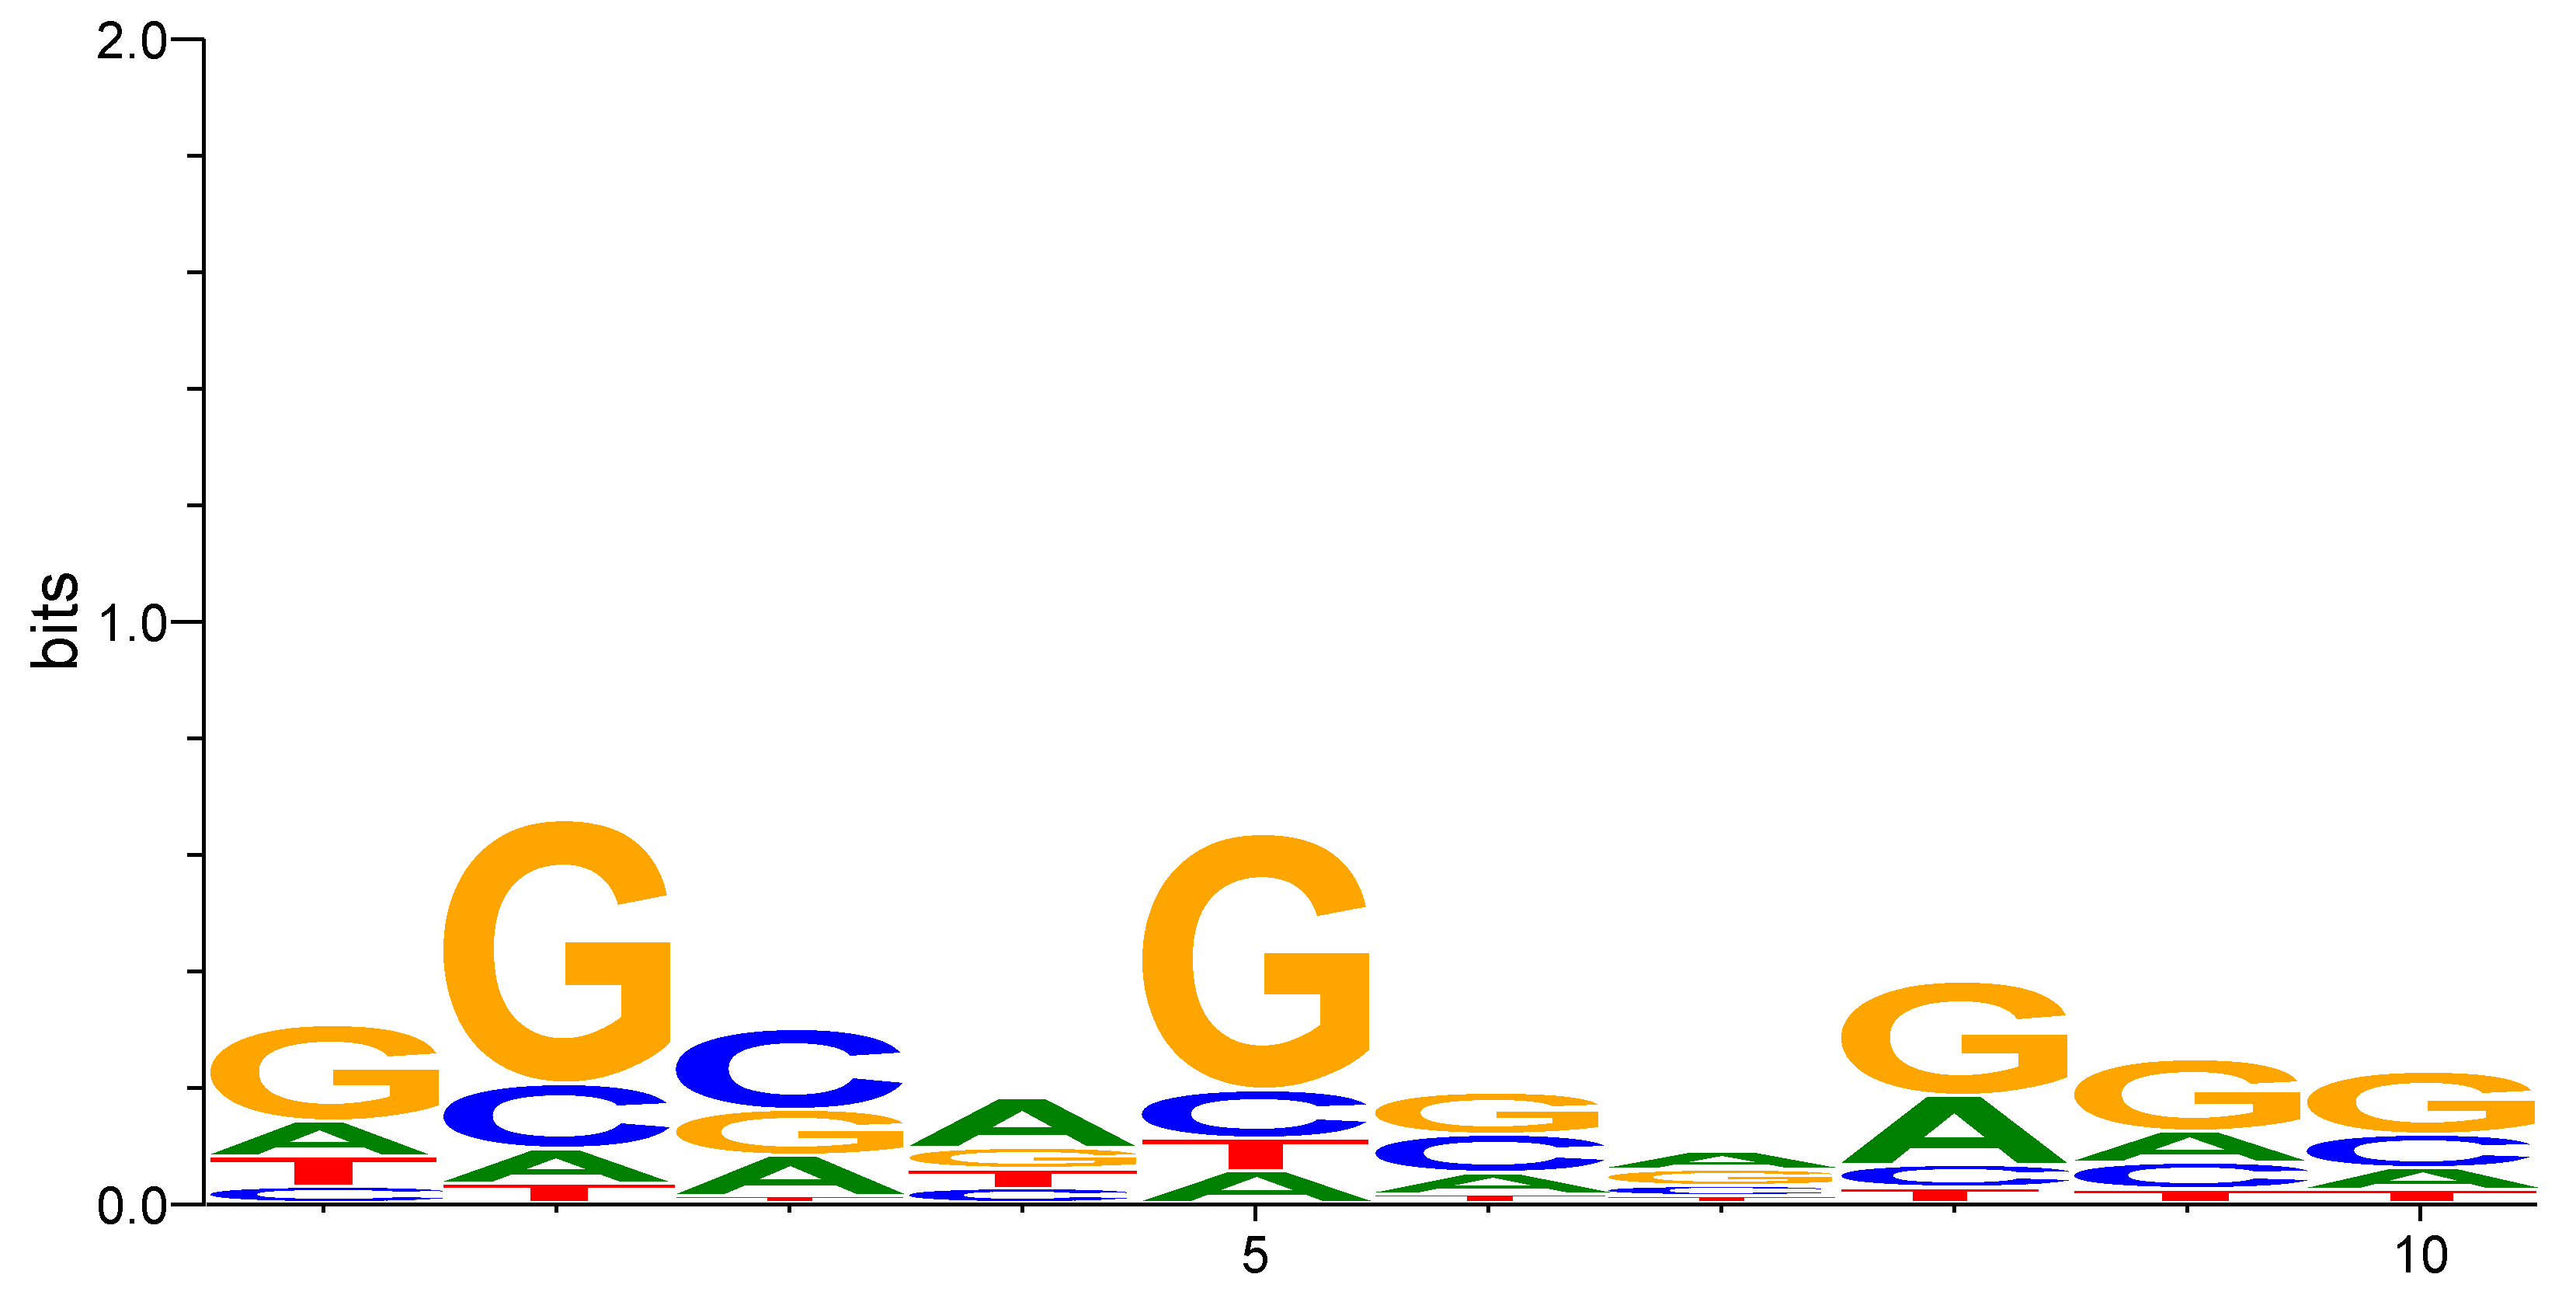

In [19]:
# Alternative Design - Subsample to 1000 peaks
random.seed(1)
# Reassigns nrf1_peaks to a smaller list
nrf1_peaks_sample = random.sample(nrf1_peaks, 1000)
# Run the gibbs sampler:
nrf1_pfm_sample = GibbsMotifFinder(nrf1_peaks_sample, 10)
# Plot the final pfm that is generated:
seqlogo.seqlogo(seqlogo.CompletePm(pfm = nrf1_pfm_sample.T))


In [20]:
# Print result with % for easy interpretation :
print(nrf1_pfm_sample)
print(pfm_ic(nrf1_pfm_sample))
bases = ['A', 'C', 'G', 'T']
k = nrf1_pfm_sample.shape[1]
total = int(nrf1_pfm_sample.sum(axis=0)[0])

labels = []
for pos in range(k):
    col = nrf1_pfm_sample[:, pos]
    winner = bases[col.argmax()]
    pct = col.max() / total * 100
    labels.append(f"Pos {pos + 1}({winner}, {pct:.0f}%)")
print(' | '.join(labels))

[[199  90 230 476  86 199 347 313 218 168]
 [ 91 171 466 138 132 344 190 102 181 251]
 [539 687 262 201 693 379 321 516 503 481]
 [171  52  42 185  89  78 142  69  98 100]]
3.2037642261731145
Pos 1(G, 54%) | Pos 2(G, 69%) | Pos 3(C, 47%) | Pos 4(A, 48%) | Pos 5(G, 69%) | Pos 6(G, 38%) | Pos 7(A, 35%) | Pos 8(G, 52%) | Pos 9(G, 50%) | Pos 10(G, 48%)
